# Capstone Project
## Optimizing Fund Allocation for Emission Reduction

For a given level of government expenditure, what is the optimal distribution of funds between EV adoption and renewable energy generation to minimize emissions?

In [2]:
# Import modules
import itertools
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
import dataframe_image as dfi # TODO: dfi.export(comm_vehicles, 'comm_vehicles.png', dpi=300)

In [3]:
# Define constants

# Unit conversions
KG_TO_LBS = 2.20462
LBS_TO_KG = 1 / KG_TO_LBS

MI_TO_K = 1.60934
K_TO_MI = 1 / MI_TO_K

GALLON_GAS_KG_CO2 = 9.46
PROD_KG_CO2_GALLON_GAS = 1.36
PROD_KG_CO2_KWH_ELECTRICTY = 0.3674 # TODO:

KWH_PER_GAL = 33.7
GAL_PER_KWH = 1 / KWH_PER_GAL

DEC_TO_PCT = 100
PCT_TO_DEC = 1 / DEC_TO_PCT

MWH_TO_KWH = 1000
KWH_TO_MWH = 1 / MWH_TO_KWH

# Categories
VEHICLE_CATEGORIES = ['ICE', 'PHEV', 'BEV']
VEHICLE_TYPES = ['Sedan', 'SUV', 'Truck']
VTYPE_COLOR_MAP = {'ICE': 'tab:orange', 'PHEV': 'tab:blue', 'BEV': 'tab:green'}
ELEC_PRODUCTION_CATEGORIES = ['Wind Turbine', 'Solar Panel', 'Natural Gas']
EPROD_COLOR_MAP = {'Wind Turbine': 'tab:green', 'Solar Panel': 'tab:blue', 'Natural Gas': 'tab:gray'}

# Assumptions
MI_PER_YR = 12000 # TODO: 

APR = 0.067
RISK_FREE_RATE = 0.04
LOAN_MONTHS = 60

GAL_GAS_COST = 3.20
KWH_ELEC_COST = 0.25

ICE_MATENENCE_COST_YR = 0.066
BEV_MATENENCE_COST_YR = 0.042

ICE_INSURANCE_PER_MI = 0.1
BEV_INSURANCE_PER_MI = 0.12

## Comparison of Lifetime Emissions of ICE, PHEV, and BEV vehicles

### Most Common Vehicles

In [6]:
# File names of data
COMM_VEHICLES = 'data/common_vehicles.csv'
MATERIAL_RATIOS = 'data/production_material_ratios.csv'
PROD_CO2_KG = 'data/production_co2_per_kg.csv'
WEIBULL_PARAMS = 'data/weibull_parameters.csv'

<Figure size 1200x600 with 0 Axes>

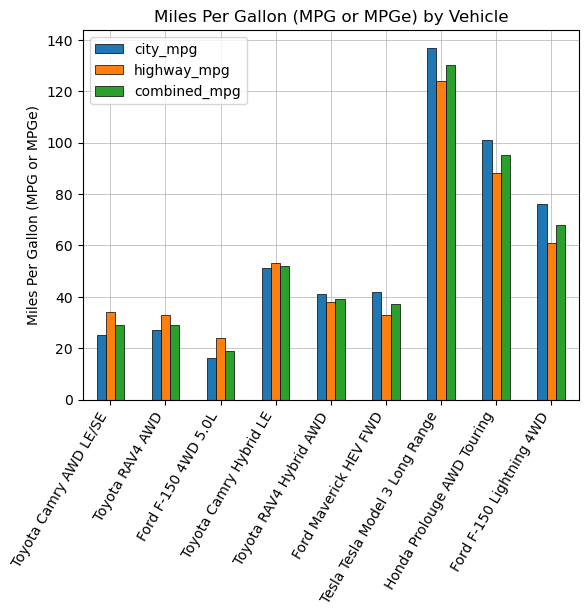

In [7]:
# Most common vehicles
comm_vehicles = pd.read_csv(COMM_VEHICLES)
comm_vehicles['vehicle'] = comm_vehicles['brand'] + ' ' + comm_vehicles['model']

# Plot
plt.figure(figsize=(12, 6))
ax = comm_vehicles.plot.bar(x='vehicle', y=['city_mpg', 'highway_mpg', 'combined_mpg'], rot=60, title='Miles Per Gallon (MPG or MPGe) by Vehicle', ec='black', lw=0.5, zorder=2)
_ = ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=60)
_ = ax.set_xlabel('') # remove x label
_ = ax.set_ylabel('Miles Per Gallon (MPG or MPGe)')
_ = ax.grid(True, zorder=1, lw=0.5)

### Manufactoring CO2 Emissions

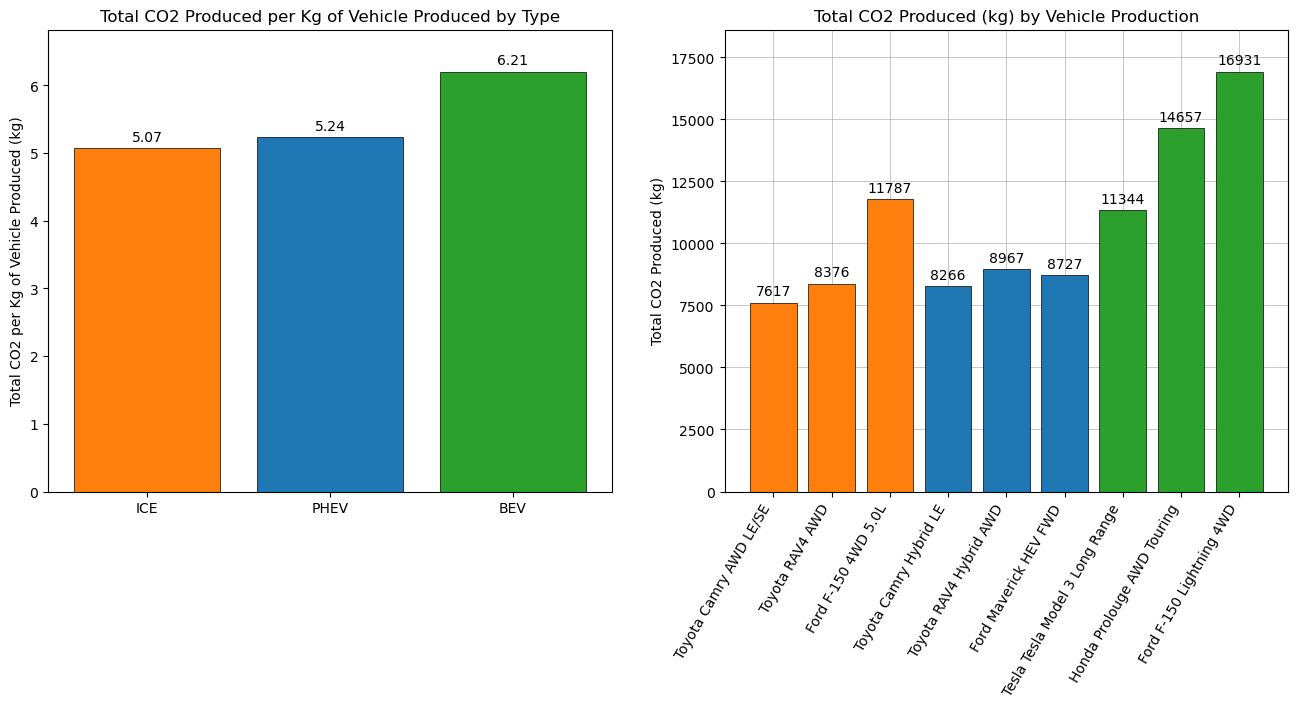

In [9]:
# Manufactoring emissions 
material_ratios = pd.read_csv(MATERIAL_RATIOS)
production_co2 = pd.read_csv(PROD_CO2_KG)

# Convert data to correct types
comm_vehicles['weight_kg'] = comm_vehicles['weight_lbs'] * LBS_TO_KG # vehicle weights in kg rather than lbs
material_ratios = material_ratios.apply(lambda x: pd.to_numeric(x, errors='coerce') / 100 if x.dtype != 'object' else x)

# Reorder materials in dataframes to multiply matrices
material_cols = material_ratios.drop('vehicle_category', axis=1).columns
production_co2 = production_co2.set_index('material').loc[material_cols]

# Multiply Ratios
material_matrix = material_ratios.drop('vehicle_category', axis=1).to_numpy()
prod_co2_matrix = production_co2.to_numpy()
kg_co2_matrix = material_matrix @ prod_co2_matrix
kg_co2 = pd.DataFrame({'vehicle_category': VEHICLE_CATEGORIES, 'co2_per_kg': kg_co2_matrix.reshape(1,3)[0]})

# Emmissions per each vehicle's production
comm_vehicles = comm_vehicles.merge(kg_co2, left_on='category', right_on='vehicle_category').drop(columns=['vehicle_category'])
comm_vehicles['prod_co2_kg'] = comm_vehicles['weight_kg'] * comm_vehicles['co2_per_kg']
comm_vehicles = comm_vehicles.drop(columns=['co2_per_kg'])

# Plot
plt.figure(figsize=(16, 6))

# CO2 per Kg of type produced
plt.subplot(1, 2, 1)
colors1 = [VTYPE_COLOR_MAP[category] for category in kg_co2['vehicle_category']]
barplot1 = plt.bar(x=kg_co2['vehicle_category'], height=kg_co2['co2_per_kg'], color=colors1, ec='black', lw=0.5)
plt.bar_label(barplot1, labels=[round(n, 2) for n in kg_co2['co2_per_kg']], padding=3)
plt.title('Total CO2 Produced per Kg of Vehicle Produced by Type')
plt.ylabel('Total CO2 per Kg of Vehicle Produced (kg)')
plt.ylim([0, np.max(kg_co2['co2_per_kg']) * 1.1])

# CO2 produced by vehicle
plt.subplot(1, 2, 2)
colors2 = [VTYPE_COLOR_MAP[category] for category in comm_vehicles['category']]
barplot2 = plt.bar(x=comm_vehicles['vehicle'], height=comm_vehicles['prod_co2_kg'], color=colors2, zorder=2, ec='black', lw=0.5)
plt.bar_label(barplot2, labels=[int(n) for n in comm_vehicles['prod_co2_kg']], padding=3)
plt.title('Total CO2 Produced (kg) by Vehicle Production')
plt.ylabel('Total CO2 Produced (kg)')
plt.ylim([0, np.max(comm_vehicles['prod_co2_kg']) * 1.1])
plt.grid(True, zorder=1, lw=0.5)
plt.xticks(rotation=60, ha='right')

plt.show()

1. ASSUMPTION 1 - Based on weight of average 4, 6, and 8-cyl engines, avg. 10% of vehicle weight
2. ASSUMPTION 2 - Based on weight of average hybrid battery, avg. 3% of vehicle weight (in addition to engine)
3. ASSUMPTION 3 - Based on weight of Tesla Model 3 Long Range, Ford F-150 Lightning batteries, avg. 25% of vehicle weight
4. ASSUMPTION 4 - "Ferrous metals" considered 90% high-grade steel, 10% cast iron
5. ASSUMPTION 5 - "Plastic" considered 70% thermoplastic (Polypropylene, PP), 30% thermoset (Polyurethane, PU)
6. ASSUMPTION 6 - "Electrical" considered 50% copper, 20% aluminum, 10% PVC, 10% polyethylene, 5% GRP, 5% ABS
8. ASSUMPTION 7 - "Textiles" considered 50% polyester, 30% nylon, 20% polypropylene

### Emissions per Mile

Sedan : ICE vs BEV - 13411 mi
Sedan : PHEV vs BEV - 27276 mi
SUV : ICE vs BEV - 25869 mi
SUV : PHEV vs BEV - 38680 mi
Truck : ICE vs BEV - 13279 mi
Truck : PHEV vs BEV - 74347 mi


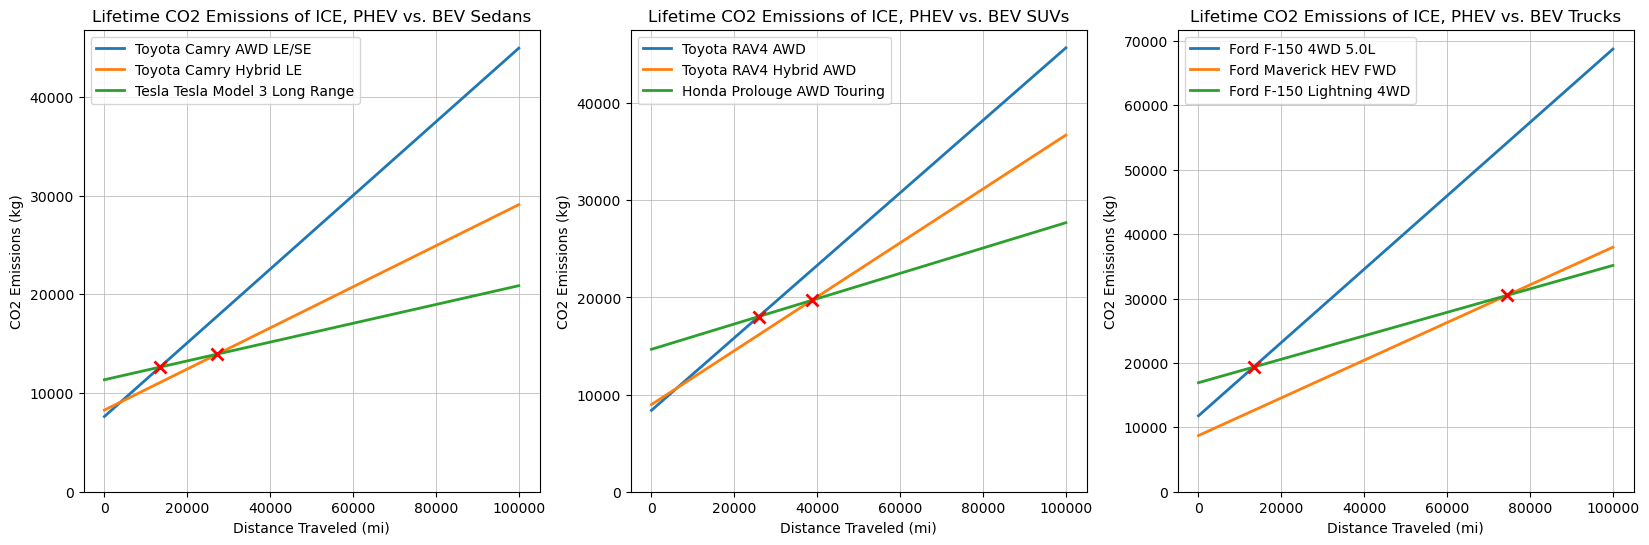

In [12]:
# Emissions per mile
kg_co2_per_gal_gas = GALLON_GAS_KG_CO2 + PROD_KG_CO2_GALLON_GAS
kg_co2_per_kwh_elec = PROD_KG_CO2_KWH_ELECTRICTY

# Kg of CO2 per mile traveled
comm_vehicles['kg_co2_per_mi'] = np.where(comm_vehicles['category'].isin(['ICE', 'PHEV']),
    (1 / comm_vehicles['combined_mpg']) * kg_co2_per_gal_gas, (KWH_PER_GAL / comm_vehicles['combined_mpg']) * kg_co2_per_kwh_elec)

#Plot
plt.figure(figsize=(20, 6))

miles = 100000

for i in range(len(VEHICLE_TYPES)):
    plt.subplot(1, len(VEHICLE_TYPES), i+1)
    temp = comm_vehicles[comm_vehicles['type'] == VEHICLE_TYPES[i]]

    # Seperate categories (for break-even values with electric cars)
    ice_phev = temp[temp['category'].isin(['ICE', 'PHEV'])]
    bevs = temp[temp['category'] == 'BEV']
    
    # Plot lifetime emissions for each vehicle
    for _, row in temp.iterrows():
        x_vals = np.array([0, miles])
        y_vals = row['prod_co2_kg'] + x_vals * row['kg_co2_per_mi']
        plt.plot(x_vals, y_vals, label=row['vehicle'], zorder=2, lw=2)

    # Plot intersections for ICE/PHEV vs BEV
    for (_, row1), (_, row2) in itertools.product(ice_phev.iterrows(), bevs.iterrows()):
        prod1, rate1 = row1['prod_co2_kg'], row1['kg_co2_per_mi']
        prod2, rate2 = row2['prod_co2_kg'], row2['kg_co2_per_mi']

        if rate1 != rate2:
            x_intersect = (prod2 - prod1) / (rate1 - rate2)
            y_intersect = prod1 + x_intersect * rate1
            plt.scatter(x_intersect, y_intersect, color='r', marker='x', zorder=3, sizes=[75], lw=2)
            
            print(f"{row1['type']} : {row1['category']} vs {row2['category']} - {int(x_intersect)} mi")
    
    plt.title(f"Lifetime CO2 Emissions of ICE, PHEV vs. BEV {VEHICLE_TYPES[i]}s")
    plt.xlabel('Distance Traveled (mi)')
    plt.ylabel('CO2 Emissions (kg)')
    plt.ylim((0, None))
    plt.grid(True, zorder=1, lw=0.5)
    plt.legend()
    
plt.show()

### Lifetime Expectancy Emissions

In [14]:
# Lifetime Expectency Functions
def weibull_cdf(t, alpha, beta):
    y = 1 - np.exp(-1 * ((t / beta) ** alpha))
    return y

def weibull_pdf(t, alpha, beta):
    y = (alpha / beta) * ((t / beta) ** (alpha - 1)) * np.exp(-1 * ((t / beta) ** alpha))
    return y

def expected_life(alpha, beta):
    """
    Function to determine the expected life of a vehicle in years

    :param alpha: Shape parameter
    :param beta: Scale parameter
    :returns: The expected life of a vehicle in years
    """
    return beta * math.gamma(1 + (1 / alpha))

def lifetime_emissions(c, mpe, mpy, ecoef, expected_life):
    """
    A function to calculate the expected lifetime emissions of a given vehicle

    :param c: Initial manufacotoring emissions in kg CO2
    :param epm: miles per unit of energy (ICE, PHEV - miles per gallon; BEV - miles per kWh)
    :param mpy: miles travled per year
    :param ecoef: coefficent of kg CO2 per unit of energy consumed (ICE, PHEV - kg/CO2 per gallon of gas; BEV - kg/CO2 per kWh of electricity)
    :param expected_life: Expected life of the vehicle in years
    :returns: The estimated lifetime emissions of a vehicle
    """
    return (c / expected_life) + (1 / mpe) * mpy * ecoef

def variance(alpha, beta):
    return (beta ** 2) * (math.gamma(1 + (2 / alpha)) - (math.gamma(1 + (1 / alpha)) ** 2)) 

def standard_dev(alpha, beta):
    return ((beta ** 2) * (math.gamma(1 + (2 / alpha)) - (math.gamma(1 + (1 / alpha)) ** 2))) ** (1 / 2)

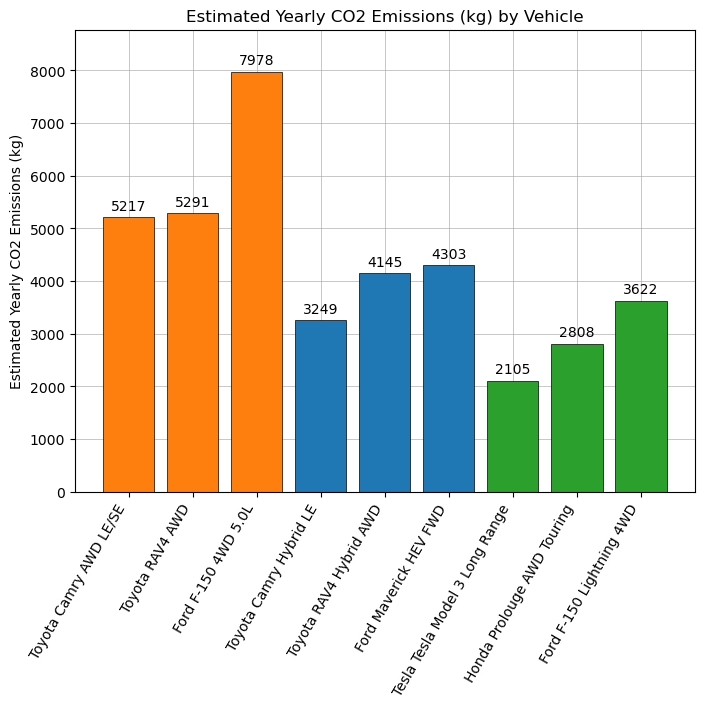

In [15]:
# Lifetime Expectency Emissions

# Weibull parameters for vehicle life expectancy
weibull_params = pd.read_csv(WEIBULL_PARAMS)
v_math = comm_vehicles.merge(weibull_params, left_on='category', right_on='vehicle_category').drop(columns=['vehicle_category'])

# Expected life, miles per unit of energy, kg CO2 per unit of energy
def get_mpe(row):
    v_cat = row["category"]
    mpg_avg = row["combined_mpg"]
    if v_cat == "BEV":
        return mpg_avg / KWH_PER_GAL
    else:
        return mpg_avg

def get_ecoef(row):
    v_cat = row["category"]
    if v_cat == "BEV":
        return PROD_KG_CO2_KWH_ELECTRICTY
    else:
        return GALLON_GAS_KG_CO2 + PROD_KG_CO2_GALLON_GAS

v_math['mpe'] = v_math.apply(get_mpe, axis=1)
v_math['ecoef'] = v_math.apply(get_ecoef, axis=1)
v_math['expected_life'] = v_math.apply(lambda row: expected_life(row['alpha'], row['beta']), axis=1)

# Yearly emissions (based on expected lifetime)
v_math['yearly_emissions'] = v_math.apply(lambda row: lifetime_emissions(row['prod_co2_kg'],
                                                                                       row['mpe'],
                                                                                       MI_PER_YR,
                                                                                       row['ecoef'],
                                                                                       row['expected_life']), axis=1)

# Plot
plt.figure(figsize=(8, 6))
colors = [VTYPE_COLOR_MAP[category] for category in v_math['category']]
barplot = plt.bar(x=v_math['vehicle'], height=v_math['yearly_emissions'], color=colors, zorder=2, ec='black', lw=0.5)
plt.bar_label(barplot, labels=[int(n) for n in v_math['yearly_emissions']], padding=3)
plt.title('Estimated Yearly CO2 Emissions (kg) by Vehicle')
plt.ylabel('Estimated Yearly CO2 Emissions (kg)')
plt.ylim([0, np.max(v_math['yearly_emissions']) * 1.1])
plt.xticks(rotation=60, ha='right')
plt.grid(True, zorder=1, lw=0.5)
plt.show()

1. ASSUMPTION 1 - Based on an average of 12,000 miles driven per year

Sedan : ICE vs BEV - 1.12 yr
Sedan : PHEV vs BEV - 2.27 yr
SUV : ICE vs BEV - 2.16 yr
SUV : PHEV vs BEV - 3.22 yr
Truck : ICE vs BEV - 1.11 yr
Truck : PHEV vs BEV - 6.2 yr


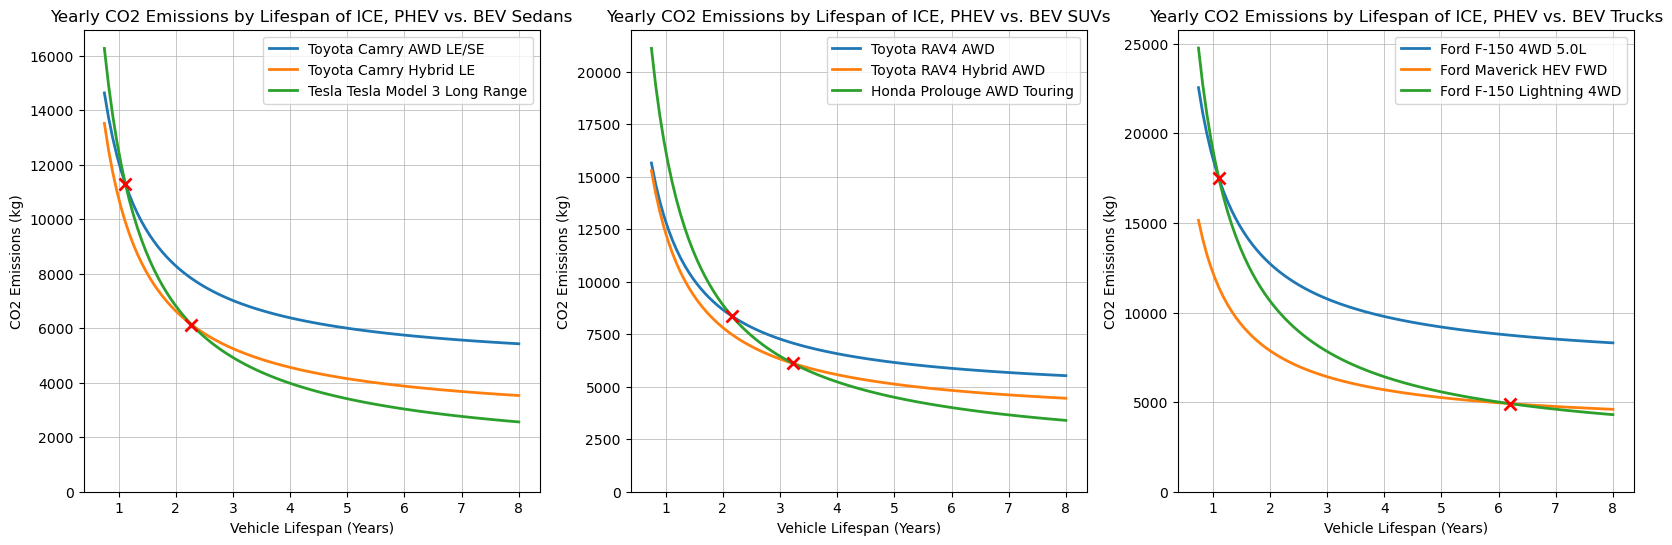

In [17]:
plt.figure(figsize=(20, 6))

for i in range(len(VEHICLE_TYPES)):
    plt.subplot(1, len(VEHICLE_TYPES), i+1)
    temp = v_math[v_math['type'] == VEHICLE_TYPES[i]]

    # Seperate categories (for break-even values with electric cars)
    ice_phev = temp[temp['category'].isin(['ICE', 'PHEV'])]
    bevs = temp[temp['category'] == 'BEV']
    
    # Plot lifetime emissions for each vehicle
    for _, row in temp.iterrows():
        x_vals = np.linspace(0.75, 8, 101)
        y_vals = (row['prod_co2_kg'] + (MI_PER_YR * x_vals) * row['kg_co2_per_mi']) / x_vals
        plt.plot(x_vals, y_vals, label=row['vehicle'], zorder=2, lw=2)

    # Plot intersections for ICE/PHEV vs BEV
    for (_, row1), (_, row2) in itertools.product(ice_phev.iterrows(), bevs.iterrows()):
        prod1, rate1 = row1['prod_co2_kg'], row1['kg_co2_per_mi']
        prod2, rate2 = row2['prod_co2_kg'], row2['kg_co2_per_mi']

        if rate1 != rate2:
            x_intersect = (prod2 - prod1) / (MI_PER_YR * (rate1 - rate2))
            y_intersect = (prod1 + (MI_PER_YR * x_intersect) * rate1) / x_intersect
            plt.scatter(x_intersect, y_intersect, color='r', marker='x', zorder=3, sizes=[75], lw=2)
            
            print(f"{row1['type']} : {row1['category']} vs {row2['category']} - {round(x_intersect, 2)} yr")
    
    plt.title(f"Yearly CO2 Emissions by Lifespan of ICE, PHEV vs. BEV {VEHICLE_TYPES[i]}s")
    plt.xlabel('Vehicle Lifespan (Years)')
    plt.ylabel('CO2 Emissions (kg)')
    plt.ylim((0, None))
    plt.grid(True, zorder=1, lw=0.5)
    plt.legend()
    
plt.show()

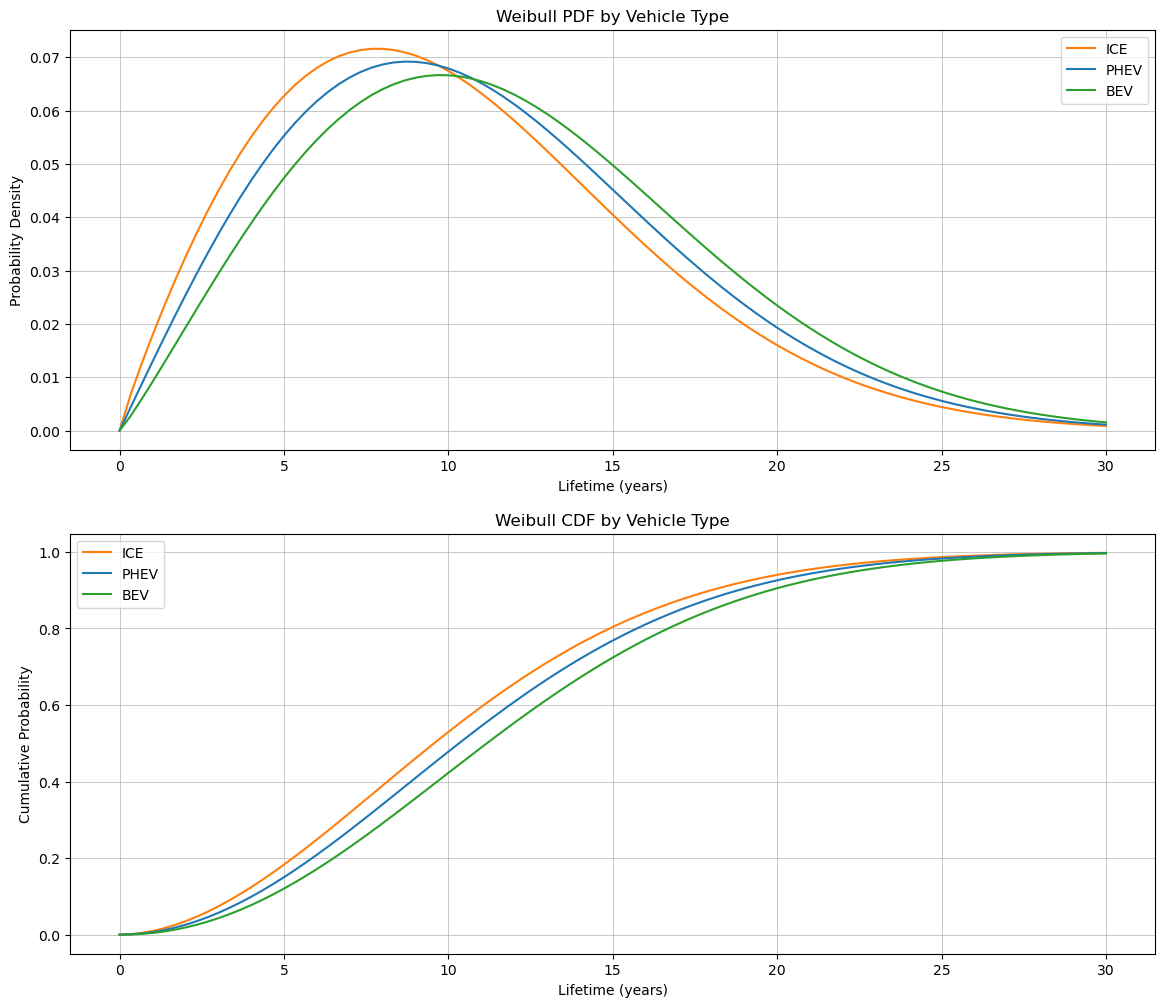

In [18]:
# Weibull PDF and CDF Plots
start_year = 0
end_year = 30
mult = 3

# Define x to calculate y's for PDF and CDF
x = np.linspace(start_year, end_year, ((end_year - start_year) * mult) + 1)

# Create the plots
plt.figure(figsize=(14, 12))

for v_cat in VEHICLE_CATEGORIES:
    v_row = weibull_params[weibull_params["vehicle_category"] == v_cat].iloc[0]
    v_alpha = v_row["alpha"]
    v_beta = v_row["beta"]
    v_color = VTYPE_COLOR_MAP[v_cat]

    # PDF
    y_pdf = weibull_pdf(x, v_alpha, v_beta)
    plt.subplot(2, 1, 1)
    plt.plot(x, y_pdf, color=v_color, label=v_cat, zorder=2)
    plt.title("Weibull PDF by Vehicle Type")
    plt.xlabel("Lifetime (years)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(lw=0.5, zorder=1)

    # CDF
    y_cdf = weibull_cdf(x, v_alpha, v_beta)
    plt.subplot(2, 1, 2)
    plt.plot(x, y_cdf, color=v_color, label=v_cat, zorder=2)
    plt.title("Weibull CDF by Vehicle Type")
    plt.xlabel("Lifetime (years)")
    plt.ylabel("Cumulative Probability")
    plt.legend()
    plt.grid(lw=0.5, zorder=1)

## Comparison of  Emissions from Wind Turbines, Solar Panels, Natural Gas Electricty Production

### CO2 Emissions per kWh

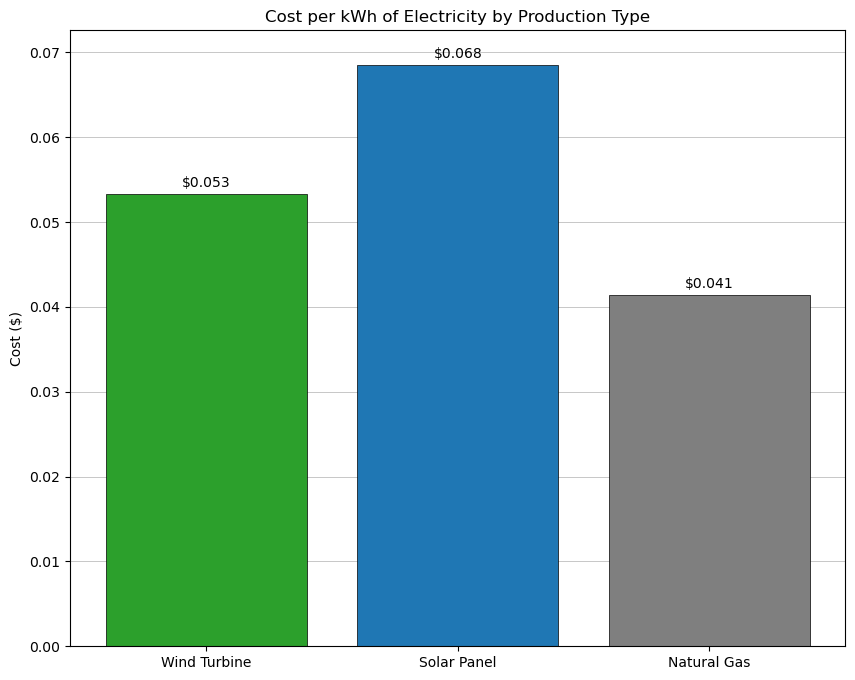

In [21]:
# LCOE values derived in Excel. Units = $ / kWh
WIND_COST = 53.31 / MWH_TO_KWH
SOLAR_COST = 68.49 / MWH_TO_KWH
NATURAL_GAS_COST = 41.42 / MWH_TO_KWH

# Values found online. Units = kg / kWh
WIND_CO2 = 1
SOLAR_CO2 = 2
NATURAL_GAS_CO2 = 3

data = {"prod_type": ['Wind Turbine', 'Solar Panel', 'Natural Gas'],
        "cost_per_kwh": [WIND_COST, SOLAR_COST, NATURAL_GAS_COST],
        "co2_per_kwh" : [WIND_CO2, SOLAR_CO2, NATURAL_GAS_CO2]}
   
elec_co2_df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 8))

colors = [EPROD_COLOR_MAP[prod_type] for prod_type in elec_co2_df['prod_type']]
barplot = plt.bar(data=elec_co2_df, x='prod_type', height='cost_per_kwh', color=colors, zorder=2, ec='black', lw=0.5)
plt.bar_label(barplot, labels=[f"${round(n, 3)}" for n in elec_co2_df['cost_per_kwh']], padding=3)
plt.ylim([0, np.max(elec_co2_df['cost_per_kwh']) * 1.06])
plt.title("Cost per kWh of Electricity by Production Type")
plt.ylabel("Cost ($)")
plt.grid(True, lw=0.5, axis='y')
plt.show()

Amount Required to be Spent for Electricity Creation per Vehicle by Production Type

Sedan - Tesla Tesla Model 3 Long Range
Wind Turbine - $165.84 | 3110.769 kg CO2
Solar Panel - $213.06 | 6221.538 kg CO2
Natural Gas - $128.85 | 9332.308 kg CO2

SUV - Honda Prolouge AWD Touring
Wind Turbine - $226.93 | 4256.842 kg CO2
Solar Panel - $291.55 | 8513.684 kg CO2
Natural Gas - $176.32 | 12770.526 kg CO2

Truck - Ford F-150 Lightning 4WD
Wind Turbine - $317.04 | 5947.059 kg CO2
Solar Panel - $407.31 | 11894.118 kg CO2
Natural Gas - $246.33 | 17841.176 kg CO2


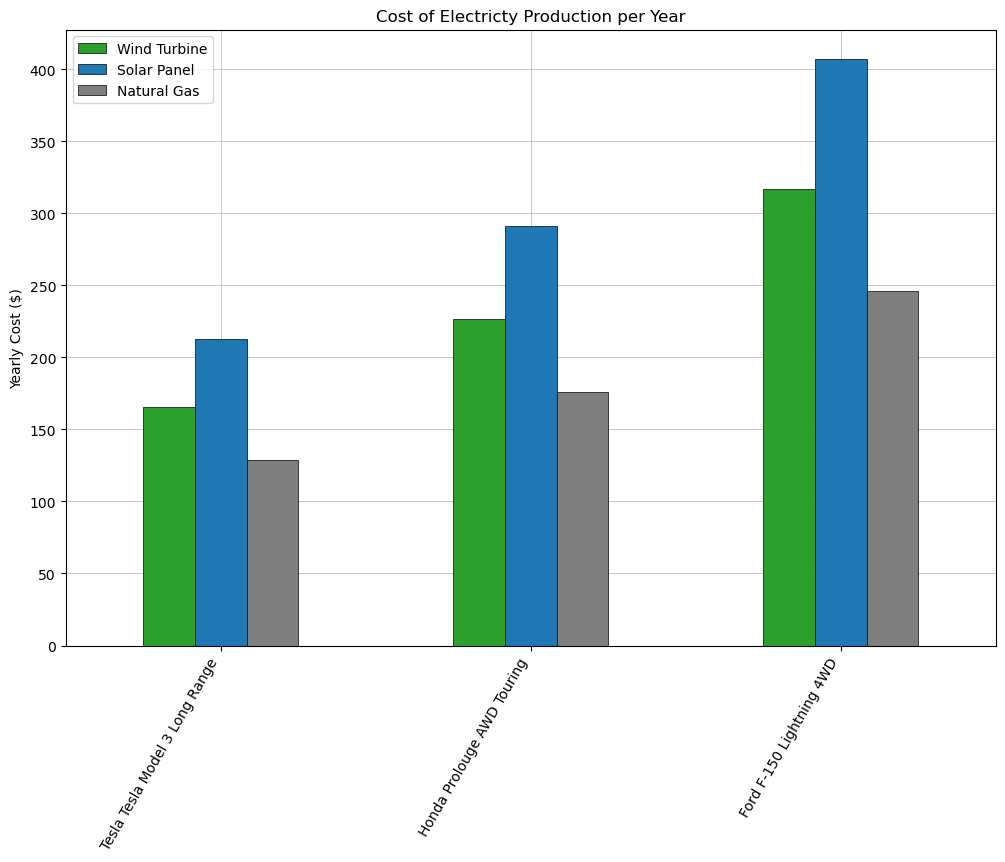

In [22]:
# Estimated amount of money spent to produce 1 year of electricty per BEV
bold = '\033[1m'
unbold = '\033[0m'

temp_dct = defaultdict(dict)

# Plot the amount of money that must be spent to create new electricity production methods per vehicle per year
print(f"{bold}Amount Required to be Spent for Electricity Creation per Vehicle by Production Type")

for idx, bev in comm_vehicles[comm_vehicles['category'] == 'BEV'].iterrows():
    print(f"\n{bold}{bev['type']} - {bev['vehicle']}{unbold}")
    combined_mpge = bev['combined_mpg']
    kwh_per_mi = KWH_PER_GAL / combined_mpge
    kwh_per_year = kwh_per_mi * MI_PER_YR
    
    for idx2, etype in elec_co2_df.iterrows():
        cost = kwh_per_year * etype['cost_per_kwh']
        co2 = kwh_per_year * etype['co2_per_kwh']
        print(f"{etype['prod_type']} - ${round(cost, 2)} | {round(co2, 3)} kg CO2")

        temp_dct[bev['vehicle']][etype['prod_type']] = cost
        
# Plot
temp_df = pd.DataFrame(dict(temp_dct)).T.reset_index(names='vehicle')

plt.figure(figsize=(12, 8))

colors = [EPROD_COLOR_MAP[ptype] for ptype in 3 * ELEC_PRODUCTION_CATEGORIES]
ax = temp_df.plot.bar(x='vehicle', y=ELEC_PRODUCTION_CATEGORIES, title='Cost of Electricty Production per Year', ec='black', lw=0.5, zorder=2, color=colors, ax = plt.gca())
_ = ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=60)
_ = ax.set_xlabel('') # remove x label
_ = ax.set_ylabel('Yearly Cost ($)')
_ = ax.grid(True, zorder=1, lw=0.5)

## Optimization Analysis

### Vehicle Subsidy Costs

In [25]:
# Subsidy required to get a rational buyer to switch from an ICE to BEV powered vehicle by comparable type
SEDAN_SUBSIDY = 11045.17
SUV_SUBSIDY = 20759.66
TRUCK_SUBSIDY = 15174.49

### Optimization

Need to decide what we will optimize, as there are a few problems that can be solved:

Given a certain amount of government expenditure (ex. $50 billion), figure out how much money should be spent to subsidize EVs and how much should be spent on eletricity infrastructure (carbon emissions per )

Must take into consideration:
1. The carbon emissions in EVs, PHEVs, and BEVs, comparing the cost in \$ of reducing 1kg of CO2 emissions
2. The carbon emissions in Solar, Wind, and Natural Gas electricity production relative to the cost in \$ per kg CO2

For example, one energy source might cost less to produce electricty but outputs more CO2. Therefore, need to determine if the money is well spent as the leftover money can be spent on subsidizing EVs, or if it its better to spend more money on energy production sources that produce less CO2 emissions, in exchange for not being able to subsidize as many EVs

Without thinking much about the calculation, the answer would seem to be, spend all the money on the item with the lowest emissions per price per kWh ratio, however we must also factor in the COST, i.e. the amount of emissions otherwised produced if not spending the money on a certain energy source or vehicle type

Two factors: money per kWh ($/kWh), CO2 emissions (kg)

Ex. (Incorrect idea) If spending $50 billion on Wind Energy, you have not saved any emissions from the vehicles themselves, therefore you are not actually making as big of an impact

Must make an assumption that all electric vehicles are currently being powered some way, therefore, we will assume that they are being powered using the current split of energy generation (wind, solar, natural gas, COAL???). Given this breakdown, we have a total estimate of how much money it costs to produce this electricity (IF USING COAL, CALCULATE LCOE), as well as an estimate for the total kg CO2 produced over the course of a year. Along with the current split of vehicles on the road (EV, PHEV, BEV and Sedan, SUV, Truck), we have an estimate for how much emissions are being produced. However, we also need to know the LCOE of gasoline and the kg CO2 per gallon in order to have an estimate of the current total emissions (and to see how best we can reduce it).

---
PERCENTAGES OF VEHICLES ON THE ROAD IN THE US

[US Electric / Hybrid Vehicles until 2023 - 3,394,792 / 9,863,152 |](https://www.bts.gov/content/gasoline-hybrid-and-electric-vehicle-sales)
[US Electric / Hybrid Vehicles 2024 - 1,300,000 / 1,900,000 |](https://www.kbb.com/car-news/america-set-ev-sales-record-in-2024/#:~:text=Americans%20bought%201.3%20million%20electric,in%202024%2C%20a%20new%20record.)
[US Total Vehicles 2024 - 296,600,000](https://hedgescompany.com/automotive-market-research-statistics/auto-mailing-lists-and-marketing/)

[US Best Selling EVs 2024 |](https://www.statista.com/statistics/257966/best-selling-electric-cars-in-the-united-states/)
[US Best Selling Gas Vehicles 2023 |](https://www.caranddriver.com/news/g43553191/bestselling-cars-2023/)
[US]

* BEV, PHEV, ICE = 1.583%, 3.966%, 94.451%
* (BEV split) Sedan, SUV, Truck = 27.494%, 63.735%, 8.771%
* (PHEV split) Sedan, SUV, Truck = 
* (ICE split) Sedan, SUV, Truck = 14.844%, 48.592%, 36.564%

---
PERCENTAGES OF ELECTRICITY GENERATION IN THE US

*Data already collected*
* Wind = 
* Solar = 
* Natural Gas = 
* Coal =

function - Emissions(x) | input (x) - dollar amount of government expenditure | output (y) - kg CO2

Function must determine emissions for a given level of government expenditure.

Function must take into account growth, i.e. orignally it might be smarter to spent more money on electricity generation (for example, if this is more eco-friendly than subsidizing electric cars)

Emissions_total = E_vehicles + E_electricity

**Decision Variables**

*Vehicle Split*
* x_sedan,bev
* x_sedan,phev
* x_suv,bev
* x_suv,phev
* x_truck,bev
* x_truck,phev

*Electricity Generation Split*
* y_solar
* y_wind

**Parameters**

*Vehicle Subsidy Costs*
* c_sedan,bev
* c_sedan,phev
* c_suv,bev
* c_suv,phev
* c_truck,bev
* c_truck,phev

*Vehicle CO2 Emmissions*
* e_sedan,bev
* e_sedan,phev
* e_sedean,ice
* e_suv,bev
* e_suv,phev
* e_suv,ice
* e_truck,bev
* e_truck,phev
* e_truck,ice

*Additional Vehicle Parameters*
* N_total: Total number of vehicles on the road in the United States
* p_sedan: Percentage (estimated) of Sedans on the road in the United States
* p_suv: Percentage (estimated) of SUVs on the road in the United States
* p_truck: Percentage (estimated) of Trucks on the road in the United States

*Cost per kWh*
* c_solar
* c_wind

*Electricity Generation CO2 Emissions*

[kg CO2 per kWh Solar, Wind Produced (0.041, 0.011)](https://www.energy.gov/eere/wind/articles/how-wind-can-help-us-breathe-easier)

[kg CO2 per kWh Solar, Wind Produced (0.044, 0.011)](https://www.joinatmos.com/blog/carbon-footprint-of-wind-turbines)

* e_solar
* e_wind

*Government Subsidy*
* B

**Equations**

* Emissions_total = E_vehicles + E_electricity
    * E_vehicles = SUM(v in {Sedan, SUV, Truck}) (N_total * p_v,ice * p_ice - x_v,bev - x_v,phev)e_v,ice + (N_total * p_v,phev * p_phev + x_v,phev)e_v,phev + (N_total * p_v,bev * p_bev + x_v,bev)e_v,bev
    * E_electricity =

**Constraints**

*Budget Constraint*
* SUM(v in {Sedan, SUV, Truck}) (x_v,bev * c_v,bev) + (x_v,phev * c_v,phev) + y_solar + y_wind <= B

*Vehicle Percentages*
* N_sedan = N_sedan,bev + N_sedan,phev + N_sedan,ice = p_sedan * N_total
* N_suv = N_suv,bev + N_suv,phev + N_suv,ice = p_suv * N_total
* N_truck = N_truck,bev + N_truck,phev + N_truck_ice = p_truck * N_total

### Using Excel Values to Calculate the Best Combination of Spending for Electric Vehicles and Electricity Generation

In [33]:
# Percentages of vehicles on the road by type
p_bev = 0.01583
p_phev = 0.03966
p_ice = 0.94451

p_sedan_bev = 0.27494
p_sedan_phev = 0.33 
p_sedan_ice = 0.14844
p_suv_bev = 0.63735
p_suv_phev = 0.34
p_suv_ice = 0.48592
p_truck_bev = 0.08771
p_truck_phev = 0.33
p_truck_ice = 0.36564

# Total percentages of vehicle catgories on the road in America
p_sedan = (p_bev * p_sedan_bev) + (p_phev * p_sedan_phev) + (p_ice * p_sedan_ice)
p_suv = (p_bev * p_suv_bev) + (p_phev * p_suv_phev) + (p_ice * p_suv_ice)
p_truck = (p_bev * p_truck_bev) + (p_phev * p_truck_phev) + (p_ice * p_truck_ice)

# Subsidy per 1 vehicle
TOTAL_SUBSIDY = (p_sedan * SEDAN_SUBSIDY) + (p_suv * SUV_SUBSIDY) + (p_truck * TRUCK_SUBSIDY)

# Percentage of vehicle categories on the road and the subsequent average subsidy
print(f"Sedan - {round(p_sedan * 100, 2)}%  |  ${SEDAN_SUBSIDY:,.2f}\n"
      f"SUV   - {round(p_suv * 100, 2)}%  |  ${SUV_SUBSIDY:,.2f}\n"
      f"Truck - {round(p_truck * 100, 2)}%  |  ${TRUCK_SUBSIDY:,.2f}\n"
      f"{'-' * 29} \n"
      f"Total - {100:.1f}%  |  ${TOTAL_SUBSIDY:,.2f}")

Sedan - 15.76%  |  $11,045.17
SUV   - 48.25%  |  $20,759.66
Truck - 35.98%  |  $15,174.49
----------------------------- 
Total - 100.0%  |  $17,218.54


In [34]:
# Import budget optimizer
from optimizer import BudgetOptimizer

# Files
SEDAN_FILE_EQUAL = "data/excel_calc_equal_sedan.csv"
SEDAN_FILE_COAL_FIRST = "data/excel_calc_coal_first_sedan.csv"
SEDAN_FILE_RANDOM = "data/excel_calc_random_sedan.csv"

SUV_FILE_EQUAL = "data/excel_calc_equal_suv.csv"
SUV_FILE_COAL_FIRST = "data/excel_calc_coal_first_suv.csv"
SUV_FILE_RANDOM = "data/excel_calc_random_suv.csv"

TRUCK_FILE_EQUAL = "data/excel_calc_equal_truck.csv"
TRUCK_FILE_COAL_FIRST = "data/excel_calc_coal_first_truck.csv"
TRUCK_FILE_RANDOM = "data/excel_calc_random_truck.csv"

TOTAL_FILE_EQUAL = "data/excel_calc_equal_total.csv"
TOTAL_FILE_COAL_FIRST = "data/excel_calc_coal_first_total.csv"
TOTAL_FILE_RANDOM = "data/excel_calc_random_total.csv"

billion = 1000000000
ton = 1000

In [35]:
# Government expenditure amount
expenditure = 200 * billion

sections = [
    [SEDAN_FILE_EQUAL, SEDAN_FILE_COAL_FIRST, SEDAN_FILE_RANDOM],
    [SUV_FILE_EQUAL, SUV_FILE_COAL_FIRST, SUV_FILE_RANDOM],
    [TRUCK_FILE_EQUAL, TRUCK_FILE_COAL_FIRST, TRUCK_FILE_RANDOM],
    [TOTAL_FILE_EQUAL, TOTAL_FILE_COAL_FIRST, TOTAL_FILE_RANDOM]
]

section_titles = ["SEDANS", "SUVS", "TRUCKS", "TOTALS"]

subsidies = [SEDAN_SUBSIDY, SUV_SUBSIDY, TRUCK_SUBSIDY, TOTAL_SUBSIDY]

reduction_types = ["Generation Reduced Equally", "Coal Reduced First", "Generation Reduced Randomly"]

# Print the entire report
for i in range(len(sections)):

    print(section_titles[i])
    
    for j in range(len(sections[i])):
        
        print("-" * 80)
        print(reduction_types[j], "\n")

        # Determine the optimal split of expenditure
        SedanOptimizer = BudgetOptimizer(sections[i][j])
        egen_red, ev_red, egen_cost, ev_cost = SedanOptimizer.optimize(TOTAL_SUBSIDY, expenditure)

        # Print the report
        SedanOptimizer.report()

    print("\n", "*" * 80, "\n", "*" * 80, "\n")

SEDANS
--------------------------------------------------------------------------------
Generation Reduced Equally 

Optimal Allocation of Funds
Total Cost: $199,731,529,298.28
Reduction : -632,137,969,077.89 kg CO2 (-0.632 Billion Metric Tons CO2)

EV  : $198,013,241,357.28 (-628,924,770,628.22 kg CO2 | -0.629 Billion Metric Tons CO2)
Egen: $1,718,287,941.00 (-3,213,198,449.67 kg CO2 | -0.003 Billion Metric Tons CO2)

--------------------------------------------------------------------------------
Coal Reduced First 

Optimal Allocation of Funds
Total Cost: $199,825,561,456.82
Reduction : -863,983,461,749.02 kg CO2 (-0.864 Billion Metric Tons CO2)

EV  : $48,211,919,634.82 (-184,754,346,386.46 kg CO2 | -0.185 Billion Metric Tons CO2)
Egen: $151,613,641,822.00 (-679,229,115,362.56 kg CO2 | -0.679 Billion Metric Tons CO2)

--------------------------------------------------------------------------------
Generation Reduced Randomly 

Optimal Allocation of Funds
Total Cost: $199,911,153,42

In [36]:
# Calculate the exact breakdown values at differnet levels of government expenditure
# expenditure_df = pd.DataFrame(columns=["expenditure", "ev_cost", "egen_cost", "ev_reduction", "egen_reduction"])
expenditures = np.array([5, 10, 25, 50, 100, 200, 500, 750]) * billion

rows = []

for cost in expenditures:

    SedanOptimizer = BudgetOptimizer(TOTAL_FILE_RANDOM)
    egen_red, ev_red, egen_cost, ev_cost = SedanOptimizer.optimize(TOTAL_SUBSIDY, cost)

    row = {
        "expenditure": f"${cost:,}",
        "ev_cost": f"${ev_cost:,.0f}", 
        "egen_cost": f"${egen_cost:,.0f}", 
        "ev_reduction": f"{ev_red:,.0f}", 
        "egen_reduction": f"{egen_red:,.0f}",
        "pct_ev_cost": f"{ev_cost/(egen_cost + ev_cost):,.3%}",
        "pct_egen_cost": f"{egen_cost/(egen_cost + ev_cost):,.3%}"
    }
    rows.append(row)
    
expenditure_df = pd.DataFrame(rows)
expenditure_df

,expenditure,ev_cost,egen_cost,ev_reduction,egen_reduction,pct_ev_cost,pct_egen_cost
0,"$5,000,000,000","$3,443,708,545","$1,010,757,612","-7,704,374,578","-4,528,194,102",77.309%,22.691%
1,"$10,000,000,000","$8,609,271,363","$1,010,757,612","-19,260,936,444","-4,528,194,102",89.493%,10.507%
2,"$25,000,000,000","$22,384,105,545","$1,010,757,612","-50,078,434,754","-4,528,194,102",95.680%,4.320%
3,"$50,000,000,000","$1,721,854,273","$47,505,607,771","-4,053,918,473","-123,039,524,127",3.498%,96.502%
4,"$100,000,000,000","$5,165,562,818","$94,404,760,974","-12,959,653,419","-279,438,092,483",5.188%,94.812%
5,"$200,000,000,000","$15,496,688,454","$184,362,188,455","-42,989,932,944","-547,555,699,711",7.754%,92.246%
6,"$500,000,000,000","$246,225,160,992","$252,082,948,469","-735,059,649,005","-761,290,504,376",49.412%,50.588%
7,"$750,000,000,000","$497,615,884,802","$252,082,948,469","-1,485,540,129,808","-761,290,504,376",66.375%,33.625%


In [37]:
# Determine the results at various levels of expenditure
x_cost = np.linspace(0, 600, 600 + 1) * billion

# Define the files to be calculated
files = [
    SEDAN_FILE_EQUAL, SEDAN_FILE_COAL_FIRST, SEDAN_FILE_RANDOM,
    SUV_FILE_EQUAL, SUV_FILE_COAL_FIRST, SUV_FILE_RANDOM,
    TRUCK_FILE_EQUAL, TRUCK_FILE_COAL_FIRST, TRUCK_FILE_RANDOM,
    TOTAL_FILE_EQUAL, TOTAL_FILE_COAL_FIRST, TOTAL_FILE_RANDOM
]


# Define results dict
results = {}

for file in files:

    title = file.replace(".csv", "").replace("data/excel_calc_", "")
    results[title] = defaultdict(list)
    
    # Determine the values at each level of expenditure
    SedanOptimizer = BudgetOptimizer(file)

    for x in x_cost:
    
        egen_red, ev_red, egen_cost, ev_cost = SedanOptimizer.optimize(SEDAN_SUBSIDY, x)
    
        results[title]["y_total_red"].append(egen_red + ev_red)
        results[title]["y_total_cost"].append(egen_cost + ev_cost)
        results[title]["y_egen_red"].append(egen_red)
        results[title]["y_ev_red"].append(ev_red)
        results[title]["y_egen_cost"].append(egen_cost)
        results[title]["y_ev_cost"].append(ev_cost)

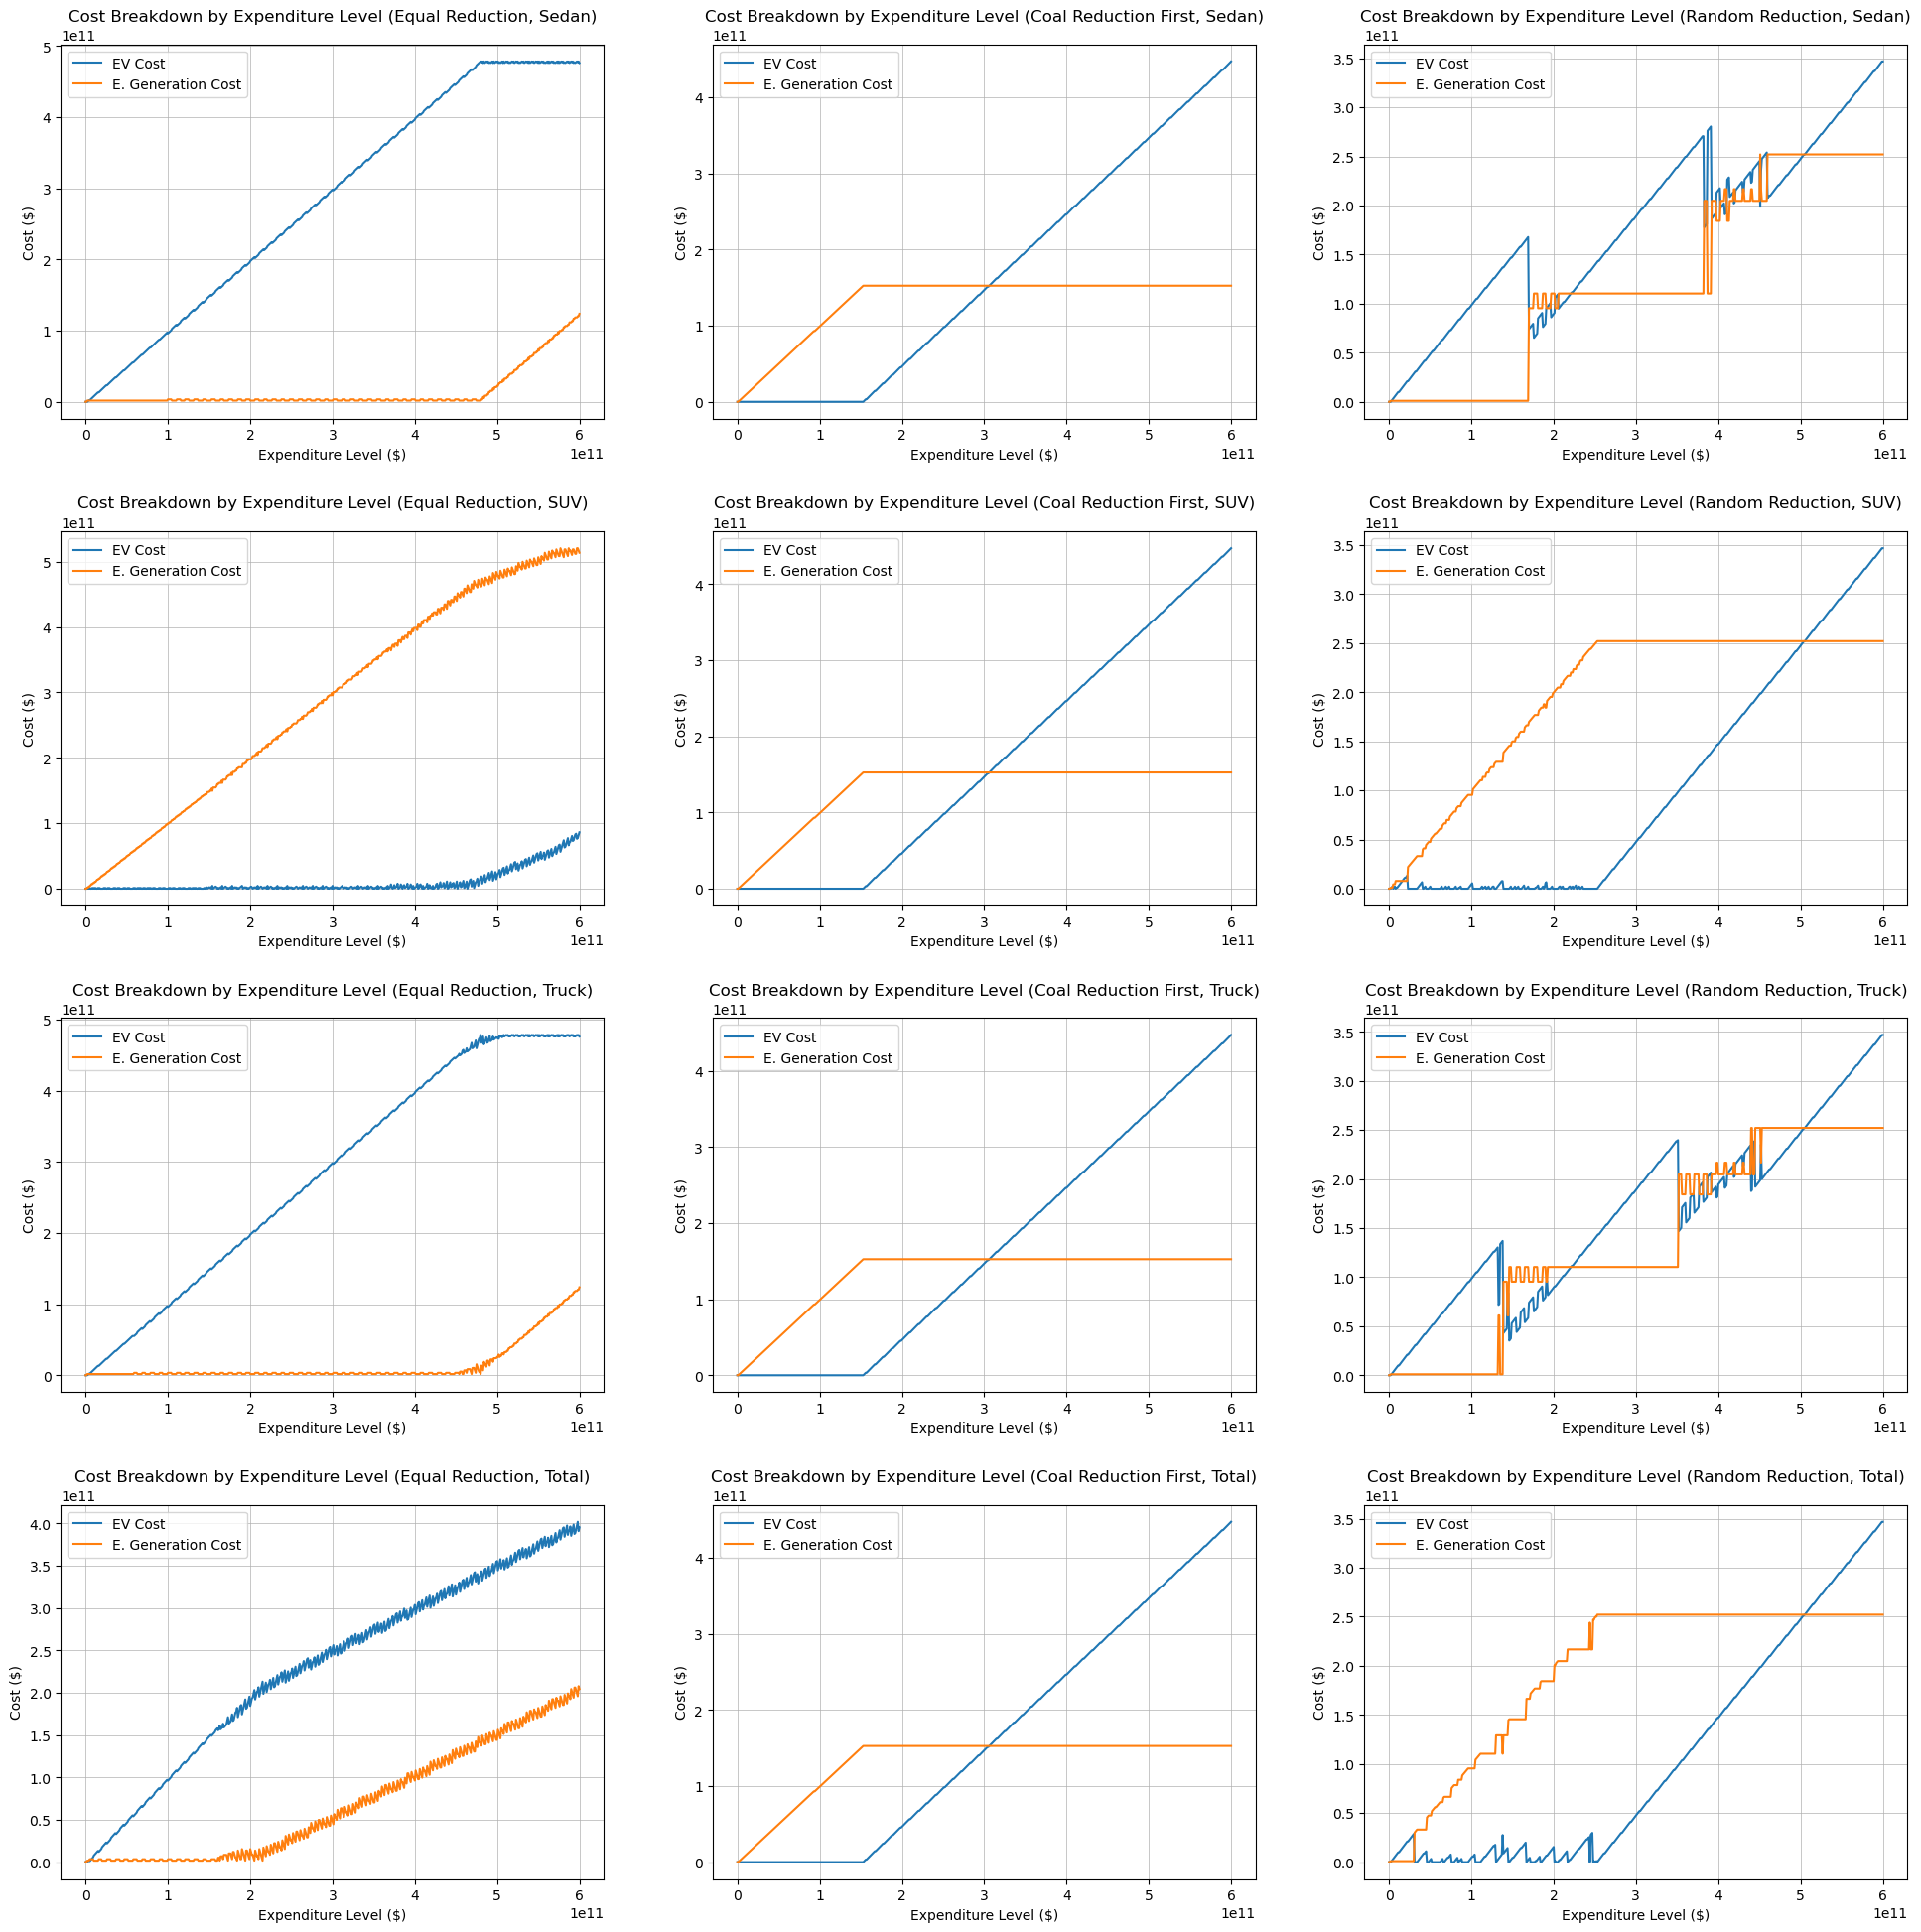

In [38]:
# Create lists of all labels and titles
keys = [file.replace(".csv", "").replace("data/excel_calc_", "") for file in files]
names = ["Equal Reduction", "Coal Reduction First", "Random Reduction"] * 4
types = VEHICLE_TYPES + ["Total"]

# Plot the figure
plt.figure(figsize=(24, 24))
plt.subplots_adjust(hspace=0.3)

for i in range(len(files)):
    
    plt.subplot(4, math.ceil(len(files)/4), i+1)

    plt.plot(x_cost, results[keys[i]]["y_ev_cost"], label="EV Cost")
    plt.plot(x_cost, results[keys[i]]["y_egen_cost"], label="E. Generation Cost")

    plt.title(f"Cost Breakdown by Expenditure Level ({names[i]}, {types[i//3]})")
    plt.xlabel("Expenditure Level ($)")
    plt.ylabel("Cost ($)")

    plt.legend()
    plt.grid(lw=0.5)

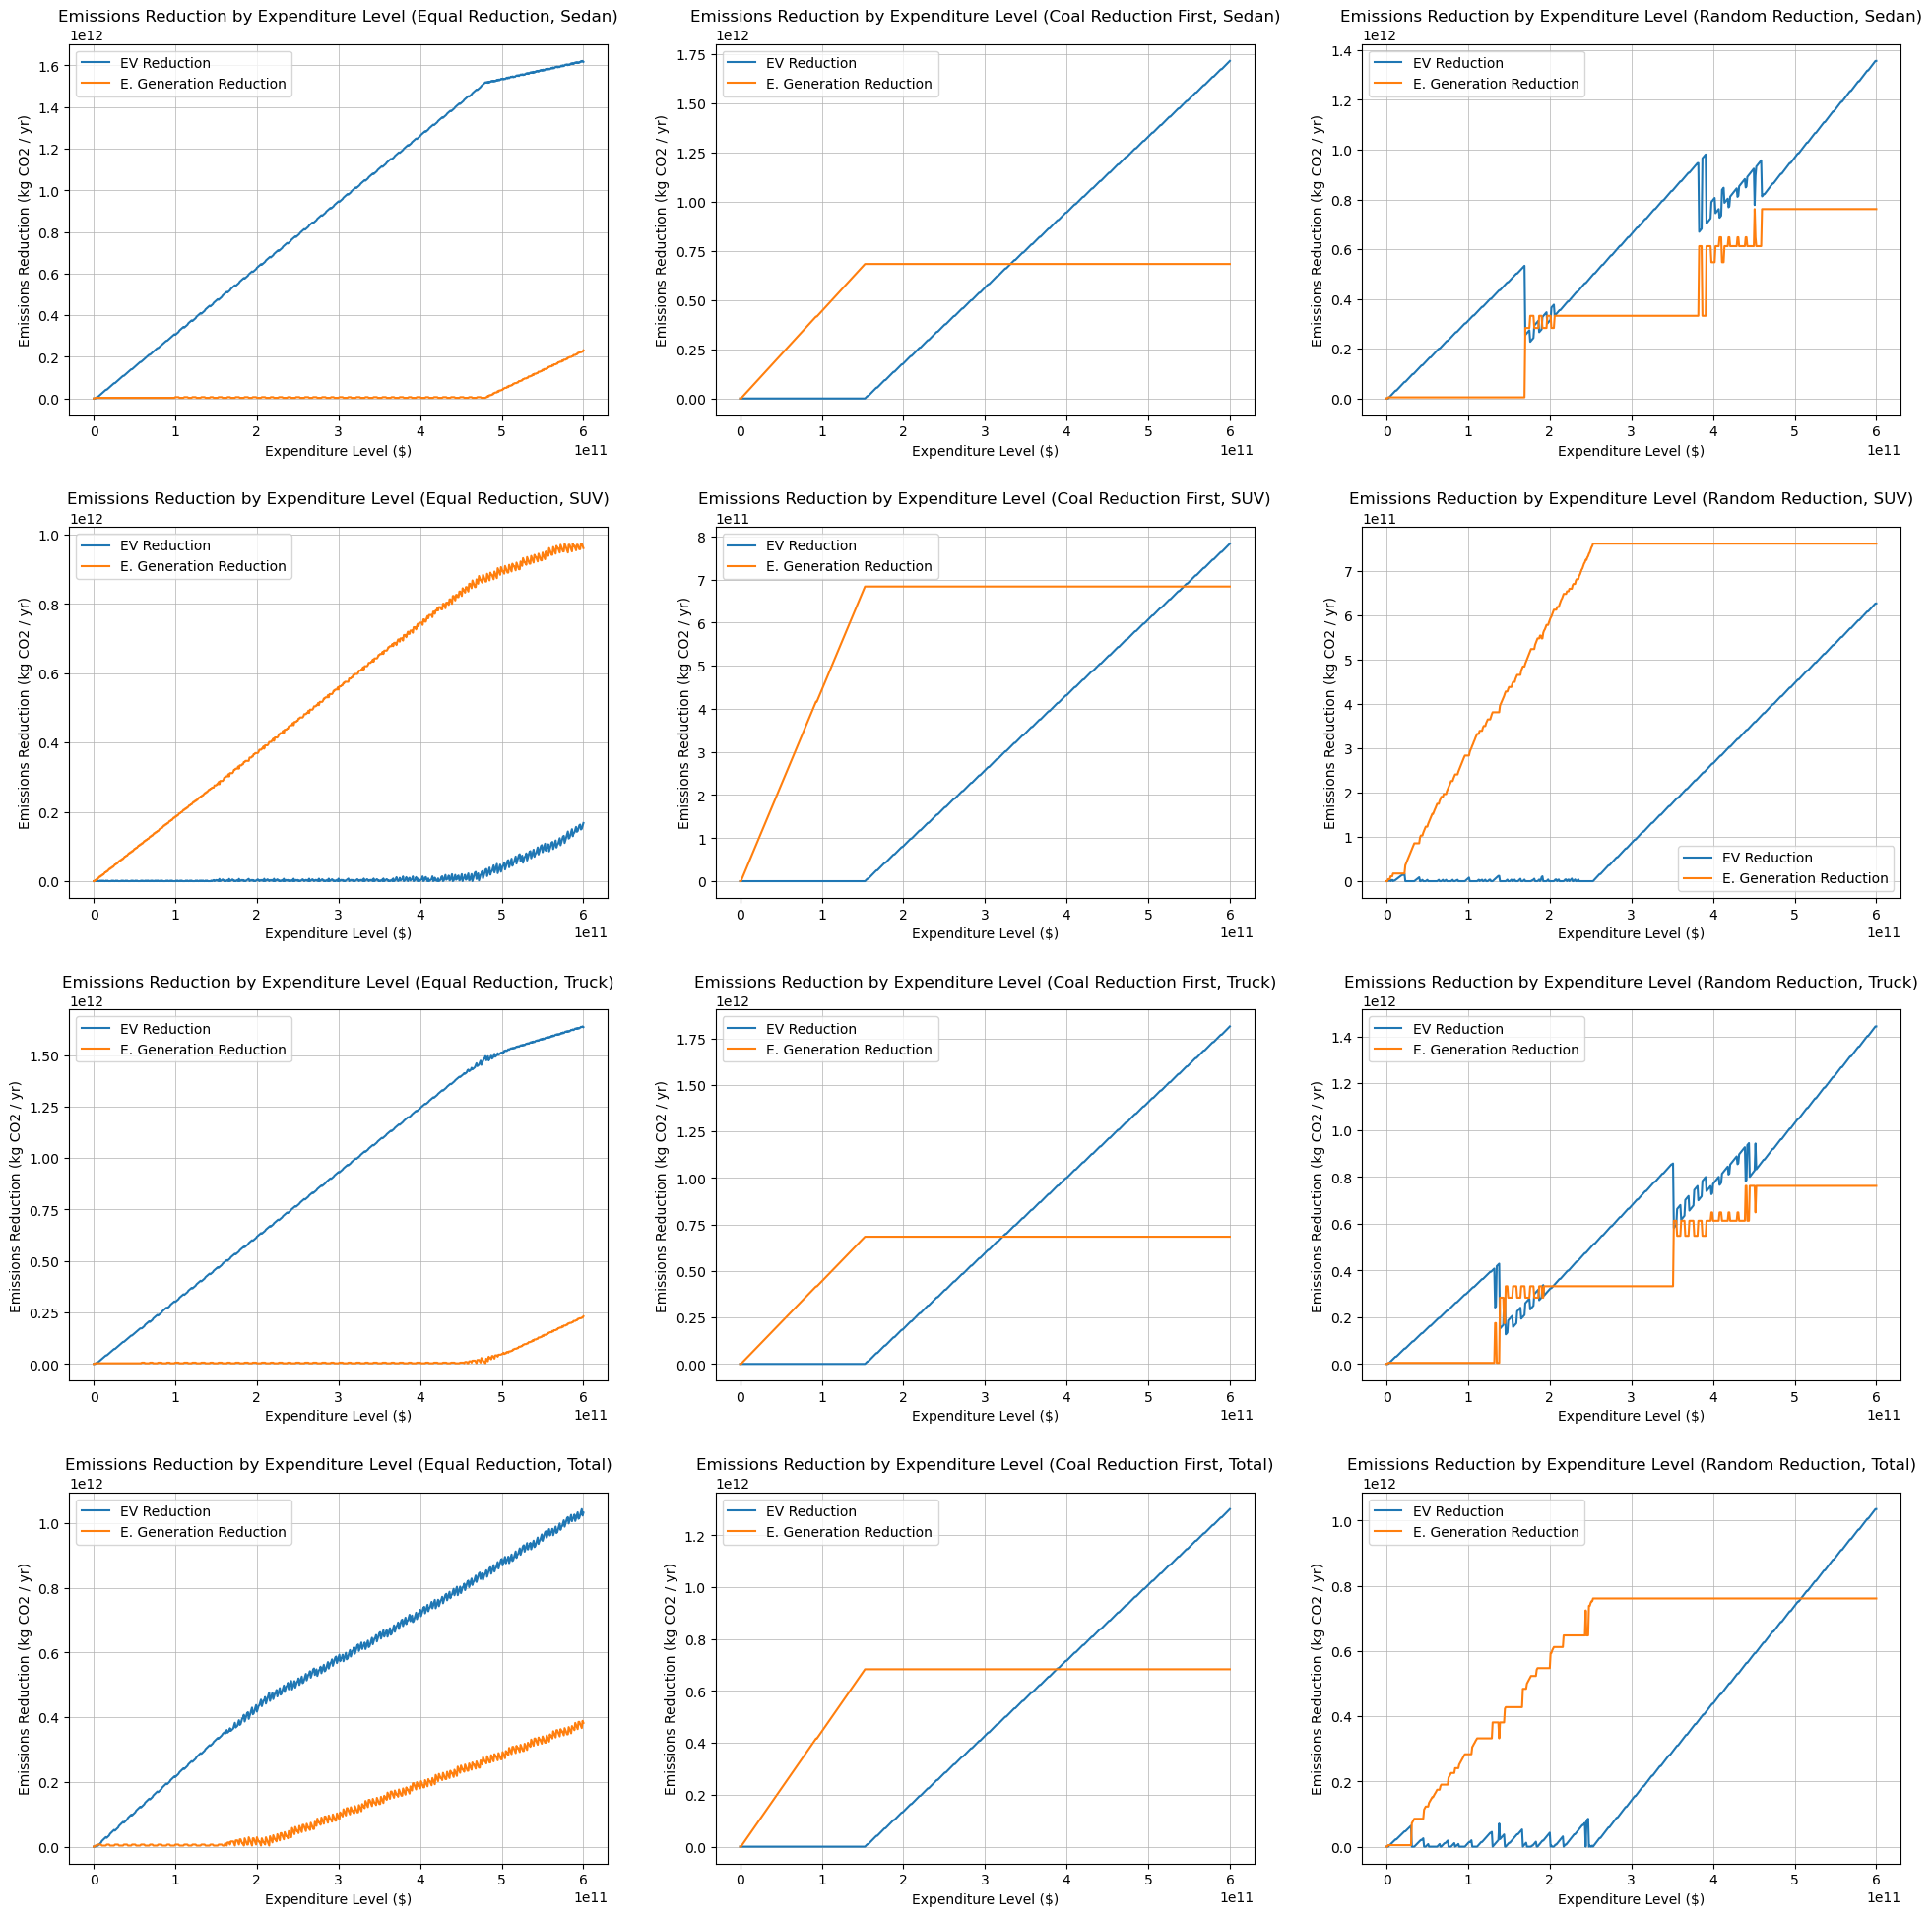

In [39]:
# Create lists of all labels and titles
keys = [file.replace(".csv", "").replace("data/excel_calc_", "") for file in files]
names = ["Equal Reduction", "Coal Reduction First", "Random Reduction"] * 4
types = VEHICLE_TYPES + ["Total"]

# Plot the figure
plt.figure(figsize=(24, 24))
plt.subplots_adjust(hspace=0.3)

for i in range(len(files)):
    
    plt.subplot(4, math.ceil(len(files)/4), i+1)

    plt.plot(x_cost, np.array(results[keys[i]]["y_ev_red"]) * -1, label="EV Reduction")
    plt.plot(x_cost, np.array(results[keys[i]]["y_egen_red"]) * -1, label="E. Generation Reduction")

    plt.title(f"Emissions Reduction by Expenditure Level ({names[i]}, {types[i//3]})")
    plt.xlabel("Expenditure Level ($)")
    plt.ylabel("Emissions Reduction (kg CO2 / yr)")

    plt.legend()
    plt.grid(lw=0.5)